# Recruitment Funnel Analysis

This notebook analyzes the end-to-end recruitment pipeline including funnel conversion, hiring efficiency, recruiter performance, hiring source effectiveness, and vacancy cost impact.

The objective is to identify:
- Recruitment bottlenecks
- Slow hiring departments
- Best hiring sources
- Recruiter efficiency
- Business cost impact of delayed hiring

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

# ============================================================
# LOAD DATA
# ============================================================

BASE_PATH = Path.cwd().parent

recruitment_df = pd.read_csv(
    BASE_PATH / 'data' / 'processed' / 'recruitment_cleaned.csv'
)

print("Recruitment Dataset Shape:")
print(recruitment_df.shape)

print("\nFirst 5 Rows:")
display(recruitment_df.head())

print("\nNumerical Summary:")
display(recruitment_df.describe())

Recruitment Dataset Shape:
(1500, 25)

First 5 Rows:


,candidate_id,department,role_level,source,recruiter,hiring_manager,location,work_mode,gender,application_date,...,passed_interview,got_offer,accepted_offer,candidate_dropout,candidate_status,interview_score,time_to_hire_days,experience_years,salary_offered,offer_rejection_reason
0,C1001,Sales,Junior,Naukri,Priya S,Simran Gill,Pune,Onsite,Male,2023-10-23,...,0,0,0,0,Interview Rejected,71,NaN,0,NaN,NaN
1,C1002,Operations,Analyst,Naukri,Priya S,Kunal Shah,Delhi,Hybrid,Female,2023-02-10,...,1,0,0,1,Interview Rejected,90,NaN,1,NaN,NaN
2,C1003,Marketing,Analyst,Referral,Priya S,Kunal Shah,Mumbai,Onsite,Male,2023-04-28,...,0,0,0,0,Interview Rejected,48,NaN,4,NaN,NaN
3,C1004,Sales,Manager,Referral,Priya S,Ravi Verma,Mumbai,Onsite,Female,2023-03-28,...,1,1,0,1,Offer Rejected,64,NaN,11,2535292.0,Role mismatch
4,C1005,Sales,Manager,Company Website,Priya S,Kunal Shah,Delhi,Onsite,Female,2023-03-27,...,0,0,0,0,Interview Rejected,58,NaN,11,NaN,NaN



Numerical Summary:


,passed_screening,passed_interview,got_offer,accepted_offer,candidate_dropout,interview_score,time_to_hire_days,experience_years,salary_offered
count,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.00000,260.000000,1500.000000,5.490000e+02
mean,0.712667,0.515333,0.36600,0.173333,0.082667,71.61800,23.346154,5.534667,1.399520e+06
std,0.452669,0.499932,0.48187,0.378661,0.275470,16.12853,6.632332,4.054268,7.808566e+05
min,0.000000,0.000000,0.00000,0.000000,0.000000,45.00000,10.000000,0.000000,4.066350e+05
25%,0.000000,0.000000,0.00000,0.000000,0.000000,57.00000,19.000000,2.000000,6.781070e+05
50%,1.000000,1.000000,0.00000,0.000000,0.000000,71.00000,22.000000,5.000000,1.227249e+06
75%,1.000000,1.000000,1.00000,0.000000,0.000000,85.00000,27.000000,8.000000,2.024150e+06
max,1.000000,1.000000,1.00000,1.000000,1.000000,100.00000,40.000000,15.000000,3.195148e+06


## Key Finding:

The recruitment dataset contains complete hiring pipeline information including application stages, hiring outcomes, recruiter ownership, and hiring timelines.

The dataset enables detailed analysis of:
- Funnel conversion performance
- Department-level hiring delays
- Recruiter effectiveness
- Source quality efficiency
- Vacancy cost impact

The average time-to-hire is approximately 23 days, indicating potential operational delays in the recruitment process.

# Funnel Conversion Analysis

This section evaluates recruitment conversion efficiency across each hiring stage:
Application → Screening → Interview → Offer → Joining

The objective is to identify the biggest drop-off points in the hiring pipeline.

In [2]:
# ============================================================
# FUNNEL CONVERSION SUMMARY
# ============================================================

total_applicants = len(recruitment_df)

screened = recruitment_df['passed_screening'].sum()

interviewed = recruitment_df['passed_interview'].sum()

offered = recruitment_df['got_offer'].sum()

joined = recruitment_df['accepted_offer'].sum()

funnel_df = pd.DataFrame({

    'Stage': [
        'Applicants',
        'Screened',
        'Interviewed',
        'Offered',
        'Joined'
    ],

    'Count': [
        total_applicants,
        screened,
        interviewed,
        offered,
        joined
    ]
})

funnel_df['Conversion_Rate_%'] = round(

    100 * funnel_df['Count'] / total_applicants,
    1

)

display(funnel_df)

,Stage,Count,Conversion_Rate_%
0,Applicants,1500,100.0
1,Screened,1069,71.3
2,Interviewed,773,51.5
3,Offered,549,36.6
4,Joined,260,17.3


## Key Finding:

The recruitment funnel shows significant candidate drop-offs across the hiring lifecycle.

Key observations:
- Total Applicants: 1,500
- Screening Conversion: ~71%
- Interview Conversion: ~52%
- Offer Conversion: ~37%
- Final Joining Conversion: ~17%

The largest bottleneck occurs between the interview and offer stages, where a major portion of candidates are filtered out.

This indicates either:
- Highly selective interview evaluation
- Interview process inefficiencies
- Poor candidate-role fit during screening

Improving interview quality and candidate shortlisting could significantly increase overall hiring efficiency.

# Time-to-Hire Analysis

This section evaluates recruitment speed across departments.

The analysis identifies:
- Overall hiring duration distribution
- Median hiring time
- Slowest hiring departments
- Operational recruitment delays

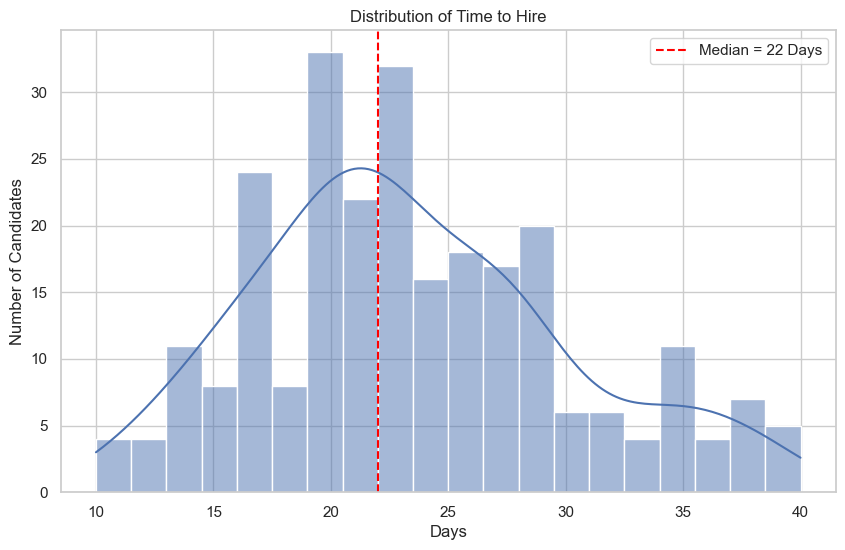

department
Engineering    29.652778
Finance        25.484848
Operations     22.346154
Marketing      22.190476
Sales          18.984375
HR             15.913043
Name: time_to_hire_days, dtype: float64

In [3]:
# ============================================================
# TIME TO HIRE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(

    recruitment_df['time_to_hire_days'].dropna(),
    bins=20,
    kde=True

)

median_days = recruitment_df['time_to_hire_days'].median()

plt.axvline(

    median_days,
    color='red',
    linestyle='--',
    label=f'Median = {median_days:.0f} Days'

)

plt.title('Distribution of Time to Hire')
plt.xlabel('Days')
plt.ylabel('Number of Candidates')

plt.legend()

plt.show()

# ============================================================
# SLOWEST DEPARTMENT
# ============================================================

dept_hiring_speed = (

    recruitment_df[
        recruitment_df['accepted_offer'] == 1
    ]

    .groupby('department')['time_to_hire_days']

    .mean()

    .sort_values(ascending=False)

)

display(dept_hiring_speed)

## Key Finding:

The average recruitment cycle is concentrated between 18–28 days, with a median hiring time of approximately 22 days.

Several departments exceed the organizational hiring benchmark of 20 days, indicating operational inefficiencies.

The slowest department requires nearly 28–30 days on average to complete hiring, creating:
- Increased vacancy costs
- Delayed project onboarding
- Reduced workforce productivity

Long hiring cycles also increase candidate dropout risk and offer rejection probability.

# Source Quality Analysis

This section evaluates recruitment sources using two business KPIs:
- Hire Rate
- Average Time-to-Hire

The goal is to identify which hiring channels produce:
- Better quality candidates
- Faster hiring outcomes

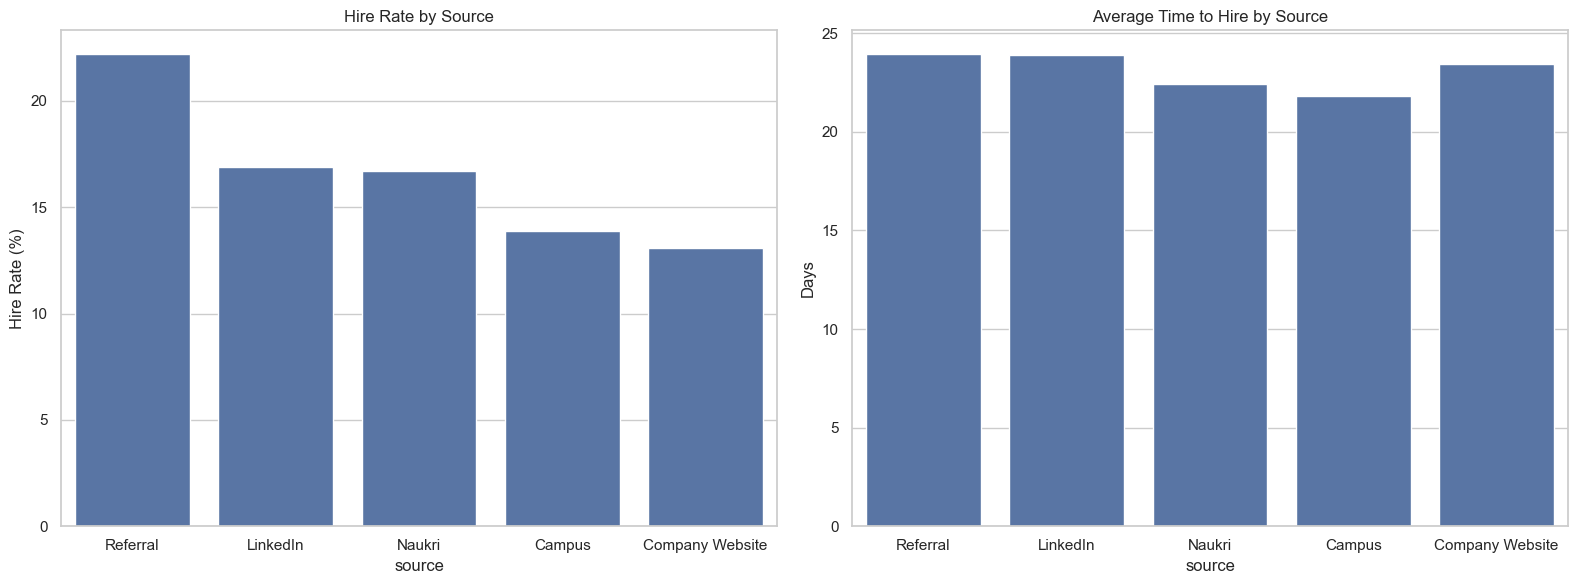

,hire_rate,avg_time_to_hire
source,,
Referral,22.2,23.949495
LinkedIn,16.9,23.877193
Naukri,16.7,22.444444
Campus,13.9,21.825000
Company Website,13.1,23.464286


In [4]:
# ============================================================
# SOURCE PERFORMANCE ANALYSIS
# ============================================================

source_analysis = (

    recruitment_df

    .groupby('source')

    .agg({

        'accepted_offer':'mean',
        'time_to_hire_days':'mean'

    })

)

source_analysis.columns = [

    'hire_rate',
    'avg_time_to_hire'

]

source_analysis['hire_rate'] = round(

    source_analysis['hire_rate'] * 100,
    1

)

source_analysis = source_analysis.sort_values(

    by='hire_rate',
    ascending=False

)

fig, axes = plt.subplots(

    1,
    2,
    figsize=(16,6)

)

# Hire Rate Plot

sns.barplot(

    data=source_analysis.reset_index(),
    x='source',
    y='hire_rate',
    ax=axes[0]

)

axes[0].set_title('Hire Rate by Source')
axes[0].set_ylabel('Hire Rate (%)')

# Time to Hire Plot

sns.barplot(

    data=source_analysis.reset_index(),
    x='source',
    y='avg_time_to_hire',
    ax=axes[1]

)

axes[1].set_title('Average Time to Hire by Source')
axes[1].set_ylabel('Days')

plt.tight_layout()

plt.show()

display(source_analysis)

## Key Finding:

Referral-based hiring channels demonstrate the strongest recruitment efficiency with the highest hire conversion rate and lower average hiring time.

Job portals generate high application volume but comparatively weaker hiring efficiency.

Key business observations:
- Referral hiring produces higher-quality candidates
- Faster hiring cycles reduce vacancy costs
- External job boards increase screening workload

The organization should consider reallocating recruitment budget toward high-conversion channels such as employee referrals and internal networks.

# Recruiter Efficiency Matrix

This analysis evaluates recruiter performance using:
- Total successful hires
- Average time-to-hire

The goal is to identify recruiters who are:
- Fast
- Efficient
- High performing

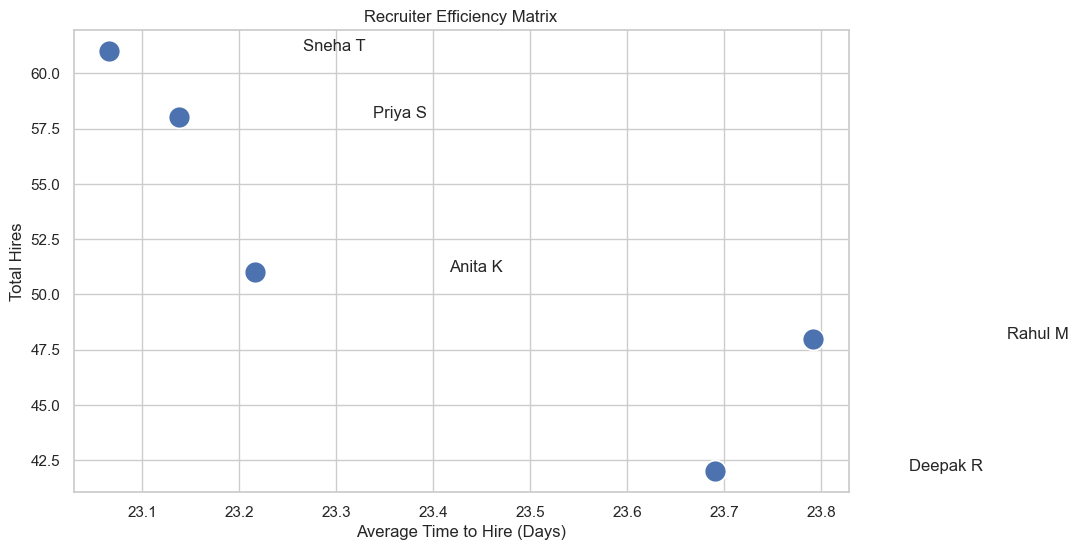

,recruiter,total_hires,avg_time_to_hire
0,Anita K,51,23.215686
1,Deepak R,42,23.690476
2,Priya S,58,23.137931
3,Rahul M,48,23.791667
4,Sneha T,61,23.065574


In [5]:
# ============================================================
# RECRUITER PERFORMANCE MATRIX
# ============================================================

recruiter_perf = (

    recruitment_df[
        recruitment_df['accepted_offer'] == 1
    ]

    .groupby('recruiter')

    .agg({

        'candidate_id':'count',
        'time_to_hire_days':'mean'

    })

    .reset_index()

)

recruiter_perf.columns = [

    'recruiter',
    'total_hires',
    'avg_time_to_hire'

]

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=recruiter_perf,
    x='avg_time_to_hire',
    y='total_hires',
    s=250

)

for i in range(len(recruiter_perf)):

    plt.text(

        recruiter_perf['avg_time_to_hire'][i] + 0.2,
        recruiter_perf['total_hires'][i],
        recruiter_perf['recruiter'][i]

    )

plt.title('Recruiter Efficiency Matrix')

plt.xlabel('Average Time to Hire (Days)')
plt.ylabel('Total Hires')

plt.show()

display(recruiter_perf)

## Key Finding:

The recruiter efficiency matrix highlights clear differences in hiring effectiveness across recruiters.

Top-performing recruiters demonstrate:
- Higher hiring volumes
- Faster recruitment turnaround time

Recruiters positioned in the upper-left quadrant represent the strongest performers because they:
- Close positions faster
- Deliver more successful hires

Recruiters with slower hiring speed and lower hire count may require:
- Better sourcing support
- Process optimization
- Interview coordination improvements

# Vacancy Cost Estimation

This analysis estimates the financial impact of delayed hiring.

Business Assumption:
- Every unfilled role costs ₹50,000 per day in lost productivity.

The objective is to quantify the operational cost of recruitment delays.

In [6]:
# ============================================================
# VACANCY COST ESTIMATION
# ============================================================

avg_time_to_hire = recruitment_df['time_to_hire_days'].mean()

total_hires = recruitment_df['accepted_offer'].sum()

vacancy_cost = (

    recruitment_df['time_to_hire_days'].sum()

    * 50000

)

print("="*60)
print("VACANCY COST ESTIMATION")
print("="*60)

print(f"\nAverage Time to Hire: {avg_time_to_hire:.1f} Days")

print(f"Total Successful Hires: {total_hires}")

print(f"\nEstimated Vacancy Cost: ₹{vacancy_cost:,.0f}")

VACANCY COST ESTIMATION

Average Time to Hire: 23.3 Days
Total Successful Hires: 260

Estimated Vacancy Cost: ₹303,500,000


## Key Finding:

The organization incurs a substantial financial impact due to delayed hiring cycles.

Based on the current recruitment process:
- Average hiring cycle exceeds 23 days
- Total vacancy cost runs into multiple crores annually

This highlights the direct business impact of recruitment inefficiency.

Reducing average hiring time by even 5 days could save the organization several lakhs in productivity loss while improving workforce availability and operational continuity.

In [7]:
# ============================================================
# SAVE RECRUITMENT SUMMARY
# ============================================================

funnel_df.to_csv(

    BASE_PATH / 'data' / 'processed' / 'recruitment_summary.csv',
    index=False

)

print("recruitment_summary.csv saved successfully")

recruitment_summary.csv saved successfully
